In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
gaia_path = '/global/cfs/cdirs/desi/users/rongpu/useful/gaia_edr3_g_14_pm_dr9.fits'
gaia = Table(fitsio.read(gaia_path))

In [4]:
tycho2 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/Tycho-2-dr9.fits'))

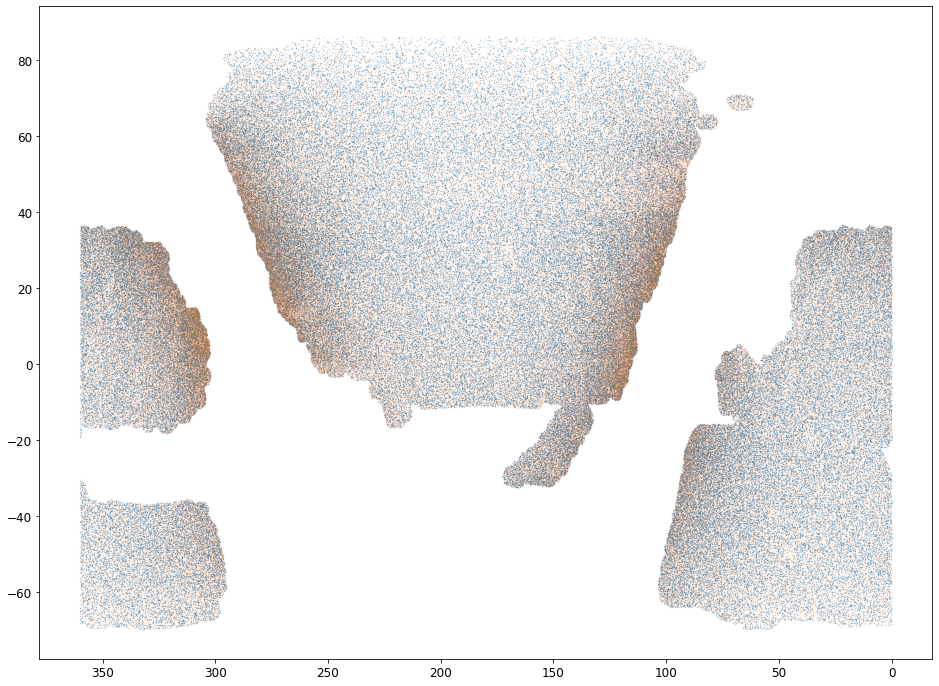

In [5]:
plt.figure(figsize=(16, 12))
plt.plot(tycho2['RA'][::5], tycho2['DEC'][::5], '.', ms=0.5, alpha=0.5)
plt.plot(gaia['RA'][::10], gaia['DEC'][::10], '.', ms=0.1, alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

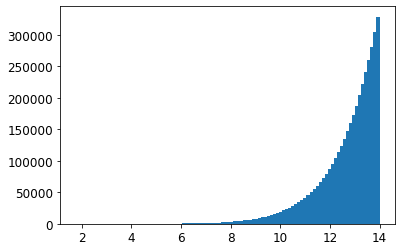

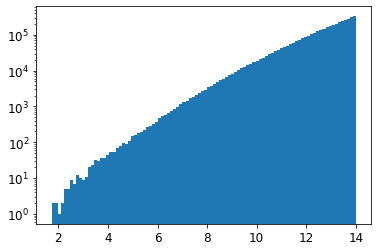

In [6]:
plt.hist(gaia['PHOT_G_MEAN_MAG'], 100)
plt.show()

plt.hist(gaia['PHOT_G_MEAN_MAG'], 100, log=True)
plt.show()

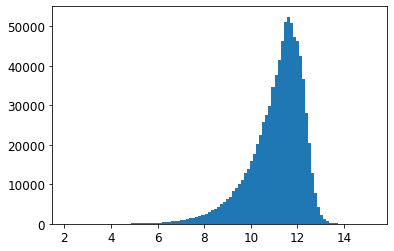

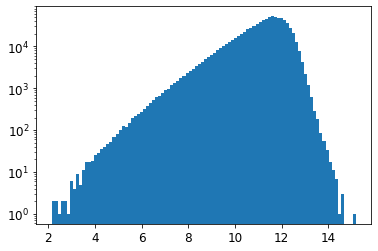

In [7]:
plt.hist(tycho2['VTmag'], 100)
plt.show()

plt.hist(tycho2['VTmag'], 100, log=True)
plt.show()

In [8]:
mask = gaia['PHOT_G_MEAN_MAG']<14
print(np.sum(mask)/len(mask))
gaia = gaia[mask]

1.0


In [9]:
mask = tycho2['VTmag']<10.
print(np.sum(mask)/len(mask))
tycho2 = tycho2[mask]

0.1489134550842469


In [10]:
gaia['RA2000'] = gaia['RA'] - 16 * gaia['PMRA'] * 1e-3/3600 / np.cos(np.radians(gaia['DEC']))
gaia['DEC2000'] = gaia['DEC'] - 16 * gaia['PMDEC'] * 1e-3/3600

In [11]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import search_around

idx1, idx2, d2d, d_ra, d_dec = search_around(gaia['RA2000'], gaia['DEC2000'], tycho2['RA'], tycho2['DEC'], search_radius=5)

132110 nearby objects


In [12]:
print(len(np.unique(idx1))/len(gaia))
print(len(np.unique(idx2))/len(tycho2))

0.032480913179318456
0.9996672792952659


In [13]:
mask_missing = np.full(len(tycho2), True)
mask_missing[idx2] = False
print(np.sum(mask_missing), np.sum(mask_missing)/len(tycho2))

42 0.0003327207047341403


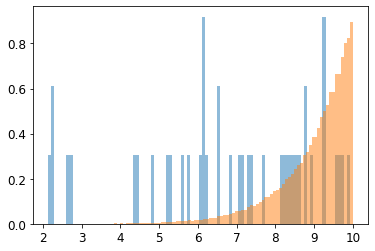

In [14]:
plt.hist(tycho2['VTmag'][mask_missing], 100, density=True, alpha=0.5)
plt.hist(tycho2['VTmag'][~mask_missing], 100, density=True, alpha=0.5)
plt.show()

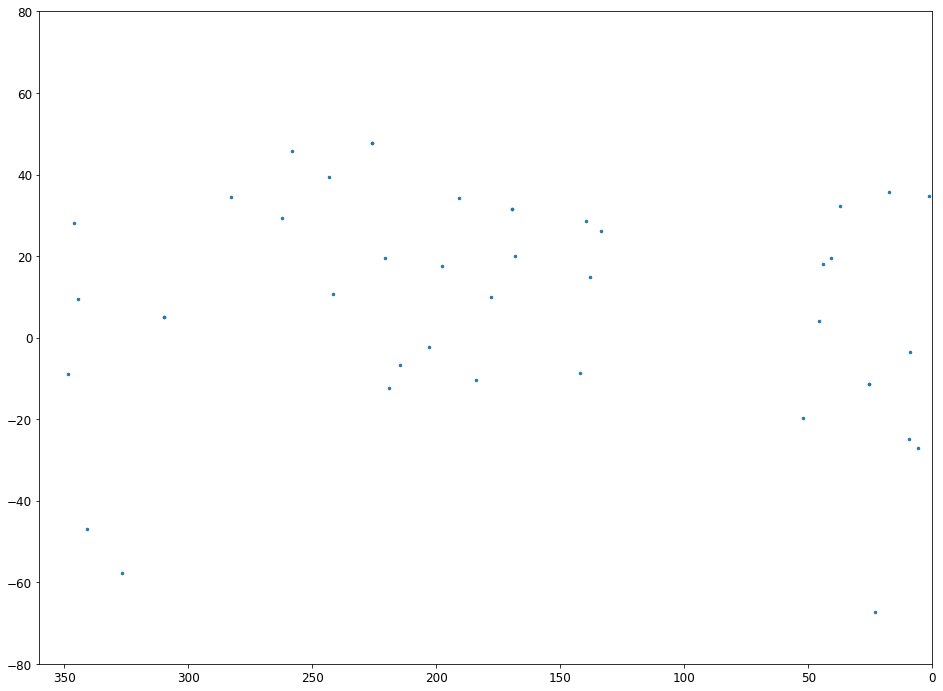

In [15]:
plt.figure(figsize=(16, 12))
plt.plot(tycho2['RA'][mask_missing], tycho2['DEC'][mask_missing], '.', ms=5, alpha=1)
plt.gca().invert_xaxis()
plt.axis([360, 0, -80, 80])
plt.show()

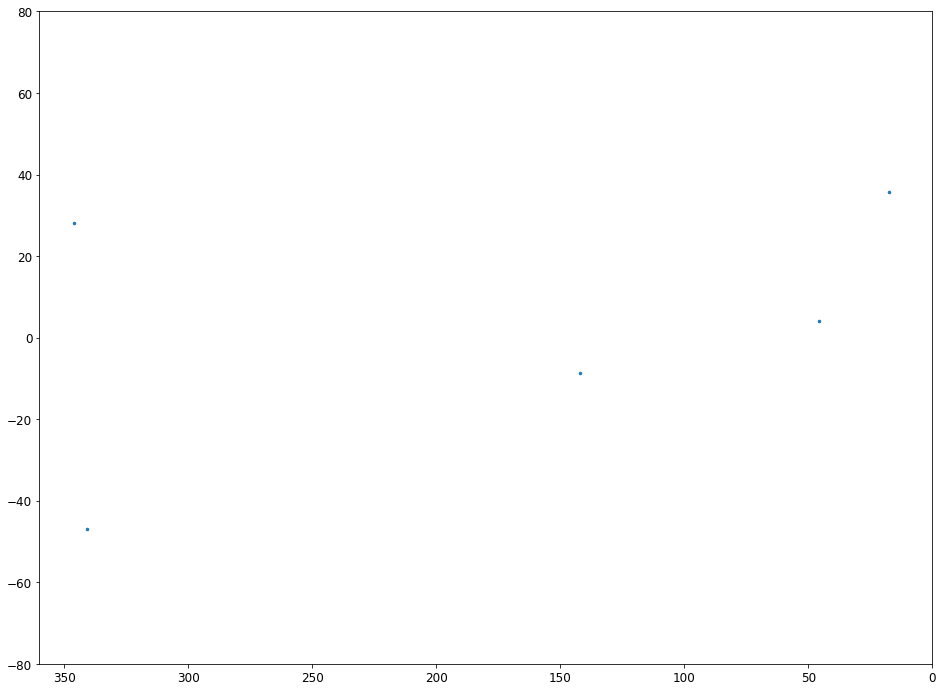

In [16]:
mask = mask_missing & (tycho2['VTmag']<4)
plt.figure(figsize=(16, 12))
plt.plot(tycho2['RA'][mask], tycho2['DEC'][mask], '.', ms=5, alpha=1)
plt.gca().invert_xaxis()
plt.axis([360, 0, -80, 80])
plt.show()

In [18]:
mask = mask_missing & (tycho2['VTmag']<4)
idx = np.where(mask)[0]
tycho2[idx]

RA,DEC,BTmag,VTmag,idx
float64,float64,float32,float32,int64
45.56988422,4.08973824,4.687,2.716,9612
345.94356931,28.08278481,4.61,2.654,507293
17.43301226,35.62055764,4.155,2.244,515959
141.89685049,-8.65860165,3.879,2.14,1315116
340.66687292,-46.88458025,4.131,2.287,2079058


In [ ]:
t = Table()
t['RA'] = tycho2['RA'][idx]
t['DEC'] = tycho2['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/visual_inspection.txt', format='ascii.no_header', overwrite=True)

In [24]:
# Remove the one outside the footprint
idx = np.delete(idx, 2)
tycho2[idx]

RA,DEC,BTmag,VTmag,idx
float64,float64,float32,float32,int64
45.56988422,4.08973824,4.687,2.716,9612
345.94356931,28.08278481,4.61,2.654,507293
141.89685049,-8.65860165,3.879,2.14,1315116
340.66687292,-46.88458025,4.131,2.287,2079058


In [25]:
t = Table()
t['RA'] = tycho2['RA'][idx]
t['DEC'] = tycho2['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/visual_inspection1.txt', format='ascii.no_header', overwrite=True)

In [28]:
tycho2_missing = tycho2[idx]
tycho2_missing.write('/global/cfs/cdirs/desi/users/rongpu/useful/Tycho-2-dr9-missing_from_gaia_edr3.fits')